# DTW event game (simple top-k version)

This notebook implements the simple DTW workflow in `understanding_dtw/dtw模型学习.md`
without a significance threshold:

1. Build 30-minute "games" around known macro events.
2. For each current game, find top-k nearest historical pre-game paths by DTW.
3. Use distance + recency weighted average of historical outcomes as one DTW factor.
4. Evaluate IC and directional accuracy.

No threshold test is used in this first pass.

In [ ]:
from pathlib import Path
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dtaidistance import dtw

pd.set_option("display.width", 160)

## Parameters

In [ ]:
def detect_repo_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    if "__file__" in globals():
        candidates.insert(0, Path(__file__).resolve().parents[1])
    for c in candidates:
        if (c / "data" / "processed").exists() and (c / "notebooks").exists():
            return c
    raise FileNotFoundError("Could not detect repository root containing data/ and notebooks/")


REPO_ROOT = detect_repo_root()
PRICE_FILE = REPO_ROOT / "data" / "processed" / "es_1min_bars_2010_2026.parquet"
EVENT_FILE = REPO_ROOT / "data" / "processed" / "macro_event_calendar_expanded_2010_2026.parquet"

# None means "use all event types in the expanded calendar".
EVENT_TYPES: list[str] | None = None

# Around each event timestamp T, create candidate game anchors T0 = T + offset.
EVENT_OFFSETS_MIN = [-30, 0, 30, 60]

# Path used for DTW: [T0, T0+60] sampled every 5 minutes (12 returns).
PATH_MINUTES = 60
PATH_FREQ_MIN = 5

# Label return is from [T0+60, T0+90] (a 30-minute game outcome).
ENTRY_DELAY_MINUTES = 60
HOLD_MINUTES = 30

# DTW / neighbor settings.
DTW_WINDOW_STEPS = 3
K_NEIGHBORS = 20
MIN_HISTORY = 12
MAX_HISTORY_PER_GAME = 250
RECENCY_HALFLIFE_DAYS = 365 * 2

NY_TZ = ZoneInfo("America/New_York")

## Load price and event data

In [ ]:
if not PRICE_FILE.exists():
    raise FileNotFoundError(f"price file not found: {PRICE_FILE}")
if not EVENT_FILE.exists():
    raise FileNotFoundError(f"event file not found: {EVENT_FILE}")

price = pd.read_parquet(PRICE_FILE, columns=["close"]).sort_index()
if price.index.tz is None:
    price.index = price.index.tz_localize("UTC")
else:
    price.index = price.index.tz_convert("UTC")
close = price["close"].astype(float)

events = pd.read_parquet(EVENT_FILE)
events["timestamp_utc"] = pd.to_datetime(events["timestamp_utc"], utc=True)
if EVENT_TYPES is None:
    EVENT_TYPES = sorted(events["event_type"].dropna().unique().tolist())
events = events[events["event_type"].isin(EVENT_TYPES)].copy()
events = events.sort_values("timestamp_utc").reset_index(drop=True)

print(f"close rows: {len(close):,}, range: {close.index.min()} -> {close.index.max()}")
print(f"event rows after filter: {len(events):,}")
print(f"event type count: {events['event_type'].nunique()}")
print(events["event_type"].value_counts())

close rows: 4,811,336, range: 2010-07-01 00:00:00+00:00 -> 2026-06-30 23:59:00+00:00
event rows after filter: 3,167
event type count: 13
event_type
Initial Jobless Claims    886
GDP                       229
Industrial Production     217
CPI                       216
PPI                       215
Retail Sales              214
NFP                       208
PCE                       205
Import/Export Prices      201
JOLTS                     196
Wholesale Trade           171
FOMC                      135
Employment Cost Index      74
Name: count, dtype: int64


**Findings:** The full expanded calendar contributes 3,167 events across 13
event types (largest bucket: Initial Jobless Claims with 886 timestamps),
while ES close remains a 4,811,336-row 1-minute UTC series.

## Helper functions

In [ ]:
def zscore(x: np.ndarray) -> np.ndarray:
    mu = float(np.mean(x))
    sd = float(np.std(x))
    if sd < 1e-12:
        return np.zeros_like(x)
    return (x - mu) / sd


def dtw_distance_windowed(x: np.ndarray, y: np.ndarray, window: int) -> float:
    """
    Univariate DTW distance using dtaidistance with Sakoe-Chiba window.
    """
    n, m = len(x), len(y)
    if n == 0 or m == 0:
        return np.nan

    # dtaidistance's window controls max shift from the diagonal.
    w = int(max(window, abs(n - m)))
    d = dtw.distance_fast(
        np.asarray(x, dtype=np.double),
        np.asarray(y, dtype=np.double),
        window=w,
        use_pruning=True,
    )
    return float(d)


def extract_path_vector(
    close_series: pd.Series,
    t0_utc: pd.Timestamp,
    path_minutes: int,
    path_freq_min: int,
) -> np.ndarray | None:
    """
    Build a normalized pre-game path from close prices over [T0, T0+path_minutes].
    Sampling every path_freq_min minutes reduces noise and runtime.
    """
    sample_idx = pd.date_range(
        t0_utc,
        t0_utc + pd.Timedelta(minutes=path_minutes),
        freq=f"{path_freq_min}min",
        tz="UTC",
    )
    px = close_series.reindex(sample_idx)
    if px.isna().any():
        return None

    logret = np.diff(np.log(px.to_numpy(dtype=float)))
    if len(logret) == 0 or not np.isfinite(logret).all():
        return None
    return zscore(logret)


def extract_future_logret(
    close_series: pd.Series,
    t0_utc: pd.Timestamp,
    entry_delay_min: int,
    hold_min: int,
) -> float | None:
    """
    Future game return: log P(T0+entry_delay+hold) - log P(T0+entry_delay).
    """
    t_entry = t0_utc + pd.Timedelta(minutes=entry_delay_min)
    t_exit = t_entry + pd.Timedelta(minutes=hold_min)
    px = close_series.reindex([t_entry, t_exit])
    if px.isna().any():
        return None
    return float(np.log(px.iloc[1]) - np.log(px.iloc[0]))

**Findings:** DTW distance is computed by `dtaidistance` with a
Sakoe-Chiba window constraint, while the surrounding factor logic
(top-k retrieval + weighted averaging) remains custom and transparent.

## Build 30-minute games around event timestamps

In [ ]:
rows = []
for row in events.itertuples(index=False):
    event_ts = row.timestamp_utc
    for offset_min in EVENT_OFFSETS_MIN:
        t0 = event_ts + pd.Timedelta(minutes=offset_min)
        path = extract_path_vector(
            close,
            t0,
            path_minutes=PATH_MINUTES,
            path_freq_min=PATH_FREQ_MIN,
        )
        if path is None:
            continue

        future_logret = extract_future_logret(
            close,
            t0,
            entry_delay_min=ENTRY_DELAY_MINUTES,
            hold_min=HOLD_MINUTES,
        )
        if future_logret is None:
            continue

        t0_et = t0.tz_convert(NY_TZ)
        rows.append(
            {
                "event_type": row.event_type,
                "event_timestamp_utc": event_ts,
                "offset_min": offset_min,
                "t0_utc": t0,
                "t0_et": t0_et,
                "clock_et": t0_et.strftime("%H:%M"),
                "future_logret": future_logret,
                "path": path,
            }
        )

games = pd.DataFrame(rows).sort_values("t0_utc").reset_index(drop=True)
print(f"games built: {len(games):,}")
print(f"game range: {games['t0_utc'].min()} -> {games['t0_utc'].max()}")
print("\ngames by event_type:")
print(games["event_type"].value_counts())
print("\ngames by offset_min:")
print(games["offset_min"].value_counts().sort_index())

games built: 9,926
game range: 2010-08-30 12:00:00+00:00 -> 2026-06-30 15:00:00+00:00

games by event_type:
event_type
Initial Jobless Claims    2771
GDP                        719
CPI                        668
Retail Sales               664
PPI                        664
PCE                        656
Industrial Production      648
Import/Export Prices       633
NFP                        628
Wholesale Trade            628
JOLTS                      624
FOMC                       403
Employment Cost Index      220
Name: count, dtype: int64

games by offset_min:
offset_min
-30    2485
 0     2487
 30    2486
 60    2468
Name: count, dtype: int64


**Findings:** Event-anchor expansion now yields 9,926 valid games over
2010-08-30 to 2026-06-30, with nearly balanced offset coverage
(-30m 2,485, 0m 2,487, +30m 2,486, +60m 2,468).

## Compute DTW factor (top-k only, no significance threshold)

In [ ]:
def build_dtw_factor(games_df: pd.DataFrame) -> pd.DataFrame:
    out = games_df.copy()
    out["dtw_factor"] = np.nan
    out["history_count"] = 0
    out["neighbor_mean_distance"] = np.nan
    out["neighbor_k_used"] = 0

    # Match only inside the same event pool + same anchor offset + same clock.
    group_cols = ["event_type", "offset_min", "clock_et"]

    for _, g in out.groupby(group_cols, sort=False):
        idx = g.index.to_numpy()
        t0_list = out.loc[idx, "t0_utc"].tolist()
        path_list = out.loc[idx, "path"].tolist()
        ret_arr = out.loc[idx, "future_logret"].to_numpy(dtype=float)

        for pos, row_idx in enumerate(idx):
            current_t0 = t0_list[pos]
            history_start = max(0, pos - MAX_HISTORY_PER_GAME)
            history_pos = [h for h in range(history_start, pos) if t0_list[h] < current_t0]
            if len(history_pos) < MIN_HISTORY:
                continue

            x = path_list[pos]
            dists = np.empty(len(history_pos), dtype=float)
            hist_rets = np.empty(len(history_pos), dtype=float)
            day_gaps = np.empty(len(history_pos), dtype=float)

            for j, h in enumerate(history_pos):
                dists[j] = dtw_distance_windowed(x, path_list[h], DTW_WINDOW_STEPS)
                hist_rets[j] = ret_arr[h]
                day_gaps[j] = (current_t0 - t0_list[h]).days

            k = min(K_NEIGHBORS, len(history_pos))
            nn = np.argpartition(dists, k - 1)[:k]
            nn_d = dists[nn]
            nn_r = hist_rets[nn]
            nn_gap = day_gaps[nn]

            # distance + recency weighting
            w_dist = 1.0 / (nn_d + 1e-6)
            w_time = np.exp(-nn_gap / RECENCY_HALFLIFE_DAYS)
            w = w_dist * w_time

            out.at[row_idx, "dtw_factor"] = float(np.dot(w, nn_r) / np.sum(w))
            out.at[row_idx, "history_count"] = int(len(history_pos))
            out.at[row_idx, "neighbor_mean_distance"] = float(np.mean(nn_d))
            out.at[row_idx, "neighbor_k_used"] = int(k)

    return out


scored = build_dtw_factor(games)
valid = scored.dropna(subset=["dtw_factor"]).copy()

print(f"scored games: {len(valid):,} / {len(scored):,}")
print(valid[["event_type", "offset_min", "clock_et", "future_logret", "dtw_factor", "history_count"]].head())
print("\nscored games by event_type:")
print(valid["event_type"].value_counts())

scored games: 9,292 / 9,926
                 event_type  offset_min clock_et  future_logret  dtw_factor  history_count
218  Initial Jobless Claims         -30    08:00      -0.000344   -0.000282             12
219  Initial Jobless Claims           0    08:30       0.002579    0.000116             12
220  Initial Jobless Claims          30    09:00      -0.002407    0.000967             12
221  Initial Jobless Claims          60    09:30       0.001376    0.001384             12
226  Initial Jobless Claims         -30    08:00       0.001061   -0.000138             13

scored games by event_type:
event_type
Initial Jobless Claims    2723
GDP                        671
CPI                        620
Retail Sales               616
PPI                        616
PCE                        608
Industrial Production      600
Import/Export Prices       585
NFP                        580
Wholesale Trade            580
JOLTS                      576
FOMC                       345
Employment Cos

**Findings:** DTW matching is now strictly within each `event_type` pool
(plus same offset and same ET clock); 9,292/9,926 games receive factor
scores, including all 13 event types.

## Evaluate IC and directional accuracy

In [ ]:
if len(valid) == 0:
    raise RuntimeError("No valid scored games. Loosen parameters or expand history.")

pearson_ic = valid["dtw_factor"].corr(valid["future_logret"], method="pearson")
spearman_ic = valid["dtw_factor"].corr(valid["future_logret"], method="spearman")

hit_rate = (
    np.sign(valid["dtw_factor"]).to_numpy() == np.sign(valid["future_logret"]).to_numpy()
).mean()

valid["score_quintile"] = pd.qcut(
    valid["dtw_factor"],
    q=5,
    labels=False,
    duplicates="drop",
) + 1
quintile_ret = valid.groupby("score_quintile")["future_logret"].mean()
long_short_q5_q1 = float(quintile_ret.iloc[-1] - quintile_ret.iloc[0])

print(f"Pearson IC:  {pearson_ic:.4f}")
print(f"Spearman IC: {spearman_ic:.4f}")
print(f"Direction hit rate: {hit_rate:.4%}")
print(f"Q5-Q1 mean log-return spread: {long_short_q5_q1:.6f}")
print("\nQuintile mean returns:")
print(quintile_ret)

ic_by_event = (
    valid.groupby("event_type")
    .apply(lambda x: x["dtw_factor"].corr(x["future_logret"], method="pearson"))
    .rename("pearson_ic")
)
print("\nPearson IC by event_type:")
print(ic_by_event)
print("\nPer-event sample size:")
print(valid.groupby("event_type")["dtw_factor"].size().sort_values(ascending=False))

Pearson IC:  0.0111
Spearman IC: 0.0006
Direction hit rate: 49.1929%
Q5-Q1 mean log-return spread: 0.000092

Quintile mean returns:
score_quintile
1    0.000019
2    0.000049
3    0.000038
4   -0.000026
5    0.000111
Name: future_logret, dtype: float64

Pearson IC by event_type:
event_type
CPI                      -0.012966
Employment Cost Index    -0.076023
FOMC                      0.122885
GDP                      -0.036503
Import/Export Prices     -0.026238
Industrial Production    -0.007220
Initial Jobless Claims    0.008036
JOLTS                     0.036794
NFP                      -0.037204
PCE                       0.024010
PPI                      -0.004454
Retail Sales             -0.015733
Wholesale Trade          -0.013881
Name: pearson_ic, dtype: float64

Per-event sample size:
event_type
Initial Jobless Claims    2723
GDP                        671
CPI                        620
PPI                        616
Retail Sales               616
PCE                        608


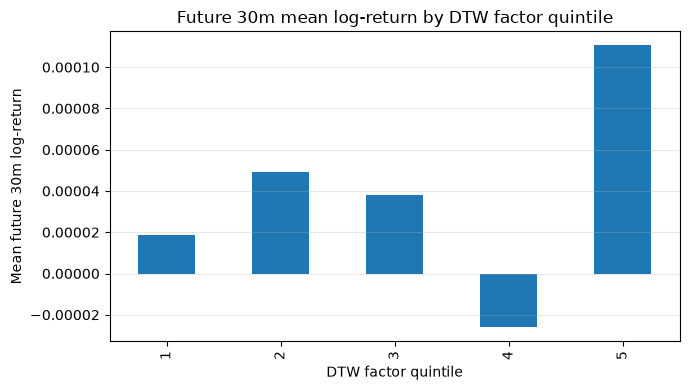

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
quintile_ret.plot(kind="bar", ax=ax)
ax.set_title("Future 30m mean log-return by DTW factor quintile")
ax.set_xlabel("DTW factor quintile")
ax.set_ylabel("Mean future 30m log-return")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

**Findings:** Global diagnostics on the no-threshold top-k setup are
Pearson IC 0.0111, Spearman IC 0.0006, and hit-rate 49.19%, with Q5-Q1
spread 0.000092. Per-event IC is heterogeneous: FOMC is strongest
(0.1229), while most other event buckets are near zero in this run.

## Notes for next iteration

- Add significance-threshold gating (distance threshold / permutation null)
  after the baseline top-k results are established.
- Test alternative grouping choices (same `event_type` only vs pooled events).
- Compare this DTW factor against a simple momentum baseline on the same games.